# VHH SMEFT predictions — NNLO QCD

This notebook computes **linear SMEFT** predictions for $W^\pm HH$ and $ZHH$ at **LO**
and **NNLO QCD** (HHZ for $ZHH$), for the LHC at 13.6 or 14 TeV.

The cross section expands as $\sigma = \sigma_{\mathrm{SM}} + \sum_i B_i C_i$
with Wilson coefficients $C_i$ in $\mathrm{TeV}^{-2}$ and $B_i$ in $\mathrm{fb\,TeV}^2$
bundled under `data/SMEFT/`.

**New here?** Edit **§1** (process, flags), **§2** (Wilson-coefficient point), **§3** (scan + plots),
then run top to bottom.

> **Run this notebook from the repository root.** The Setup cell checks for `data/SMEFT/`.

> For **HEFT** $\kappa$ predictions use [`vhh_prediction_HEFT.ipynb`](vhh_prediction_HEFT.ipynb).

## Contents

| § | What it does | Main output |
|---|---|---|
| Setup | Imports SMEFT API, checks repo root | — |
| 1 | Process, energy, output flags | `analysis` |
| 2 | Spot check at one WC point | results table (+ simulation if enabled) |
| 3 | Scan one WC axis and plot | `scan_data` + PNGs (+ optional `.txt`) |
| 4 | Multi-axis grid scan | one `.txt` with all WC combinations |
| 5 | SMEFT benchmark tables | display + optional LaTeX |


## 0. Setup

In [10]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path(".").resolve()))
from vhh_predict.notebook_setup import setup_smeft

globals().update(setup_smeft())
print(f"Repo root: {REPO_ROOT}")


Repo root: /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO


## 1. Configuration

| Variable | Meaning |
|----------|---------|
| `PROCESS` | `"WplusHH"`, `"WminusHH"`, or `"ZHH"` |
| `ENERGY_TEV` | `13.6` or `14.0` |
| `COMPARE_SIMULATION` | Compare to bundled SMEFT `.out` files in §2 only |
| `UNCERTAINTIES_AS_PERCENT` | Print uncertainties as % (`False` → fb) |
| `SAVE_SCAN_POINTS` | Write §3 scan table to `Results/Points/SMEFT/` |
| `SAVE_PLOTS` | Write §3 plot PNGs to `Results/Plots/SMEFT/` |
| `SIGMA_INSET`, `LEGEND_LOC`, `INSET_LOC` | Plot layout (§3) |

Wilson coefficients $C_i$ in $\mathrm{TeV}^{-2}$. SM point: all $C_i = 0$.

**Allowed SMEFT intervals** (global fit with RGE, Table E.1 of [ter Hoeve *et al.*, arXiv:2502.20453](https://arxiv.org/abs/2502.20453); `SMEFT_WC_INTERVALS` in `vhh_predict/smeft_operators.py`):

| Bosonic | Interval [TeV$^{-2}$] |
|---------|----------------------|
| $C_\varphi$ | [−15, 5] |
| $C_{\varphi W}$ | [−1, 1] |
| $C_{\varphi B}$ | [−0.5, 0.5] |
| $C_{\varphi WB}$ | [−1.5, 1.5] |
| $C_{\varphi D}$ | [−2, 2] |
| $C_{\varphi\square}$ | [−1.5, 1.5] |

| Fermionic | Interval [TeV$^{-2}$] |
|-----------|----------------------|
| $C_{\varphi q}^{(3)}$ | [−0.2, 0.05] |
| $C_{\varphi q}^{(1)}$ | [−3, 1] |
| $C_{\varphi u}$ | [−3.5, 1] |
| $C_{\varphi d}$ | [−4, 4] |
| $C_{t\varphi}$ | [−15, 5] |
| $C_{\varphi t}$ | [−24.4, 33.9] |
| $C_{\varphi Q}^{(3)}$ | [−7.7, 2] |
| $C_{\varphi Q}^{(1)}$ | [−6.5, 30.5] |

$B_{12}$ (ZHH NNLO only) is scanned as the combination $C_{\varphi t}+C_{\varphi Q}^{(3)}-C_{\varphi Q}^{(1)}$ (`phiQ3rd`; default scan window [−8, 2]).


In [11]:
PROCESS = "ZHH"
ENERGY_TEV = 14.0

COMPARE_SIMULATION = True
UNCERTAINTIES_AS_PERCENT = True
SAVE_SCAN_POINTS = True
SAVE_PLOTS = True

SIGMA_INSET = True
LEGEND_LOC = "lower right"
INSET_LOC = "upper left"

PLOT_STYLE = plot_style_with_layout(
    legend_loc=LEGEND_LOC,
    inset_loc=INSET_LOC,
    sigma_inset=SIGMA_INSET,
)

analysis = load_smeft_analysis(PROCESS, ENERGY_TEV)
nn_label = analysis.nnlo_label

print(f"{PROCESS} @ {ENERGY_TEV} TeV  |  scan axes: {', '.join(scan_axes(PROCESS))}")


ZHH @ 14.0 TeV  |  scan axes: phi, phiBox, phiD, phiq3st, phiW, phiq1st, phiu, phid, phiB, phiWB


## 2. Spot check

Set **`WCS`** — a dictionary of Wilson coefficients in $\mathrm{TeV}^{-2}$.
Unlisted coefficients default to 0 (SM).

Example for $ZHH$: `{"phiW": -0.2}` scans $C_{\varphi W} = -0.2$ with all other $C_i = 0$.

When `COMPARE_SIMULATION=True`, bundled `.out` files under `data/SMEFT/.../Simulation/`
are matched by filename-encoded Wilson coefficients.


In [12]:
WCS = {"phiW": -0.2, "phi": 1.0}  # SM: {} or all zeros

display(Markdown(f"### {spot_check_caption(analysis, WCS)}"))
display(
    spot_check_table(
        analysis,
        WCS,
        as_percent=UNCERTAINTIES_AS_PERCENT,
        compare_simulation=COMPARE_SIMULATION,
    )
)


### ZHH @ 14 TeV — C_φ=1, C_φW=-0.2

,Quantity,SMEFT,Scale (+/−),PDF+αs,Simulation,Δ vs simulation
0,σ_LO [fb],0.142148,+0.72% / −0.99%,±1.73%,—,—
1,σ_HHZ [fb],0.221508,+5.51% / −4.23%,±1.35%,—,—
2,σ/σ_SM (LO),0.465282,—,—,—,—
3,σ/σ_SM (HHZ),0.530841,—,—,—,—
4,K,1.55829,—,—,—,—


## 3. Scan and plots

Vary **one** Wilson coefficient; other components stay at `FIXED_WCS`.

- `scan_axis` — one of the keys printed in §1 (`phi`, `phiW`, …)
- `scan_vmin`, `scan_vmax` — scan window (defaults below use the global-fit interval)
- `scan_n_points` — grid resolution


Interval for C_φW: [-0.2, 1]
Scan / plot window:                  [-0.2, 1]
Saved /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/Results/Points/SMEFT/ZHH_14TeV_phiW.txt


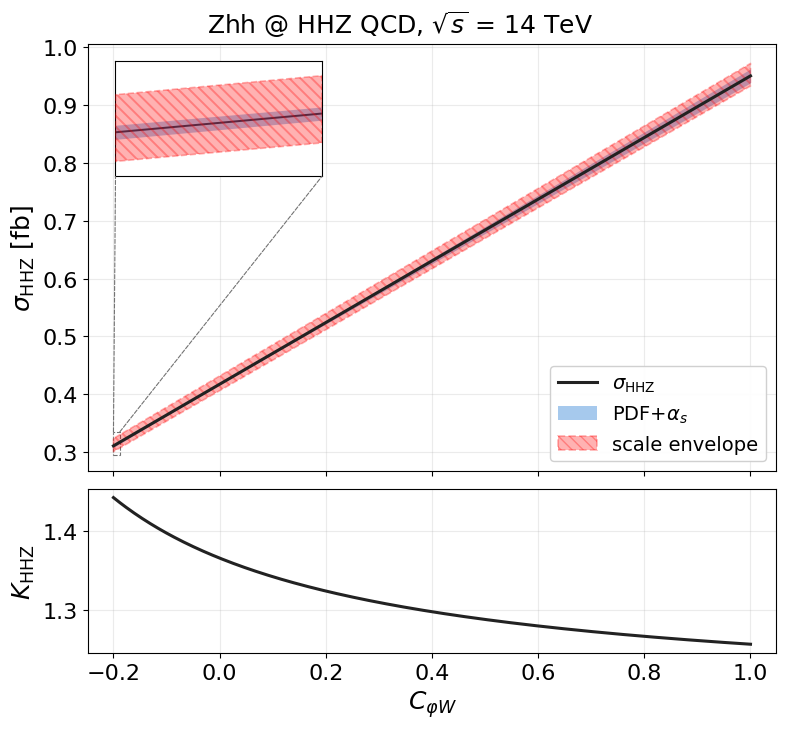

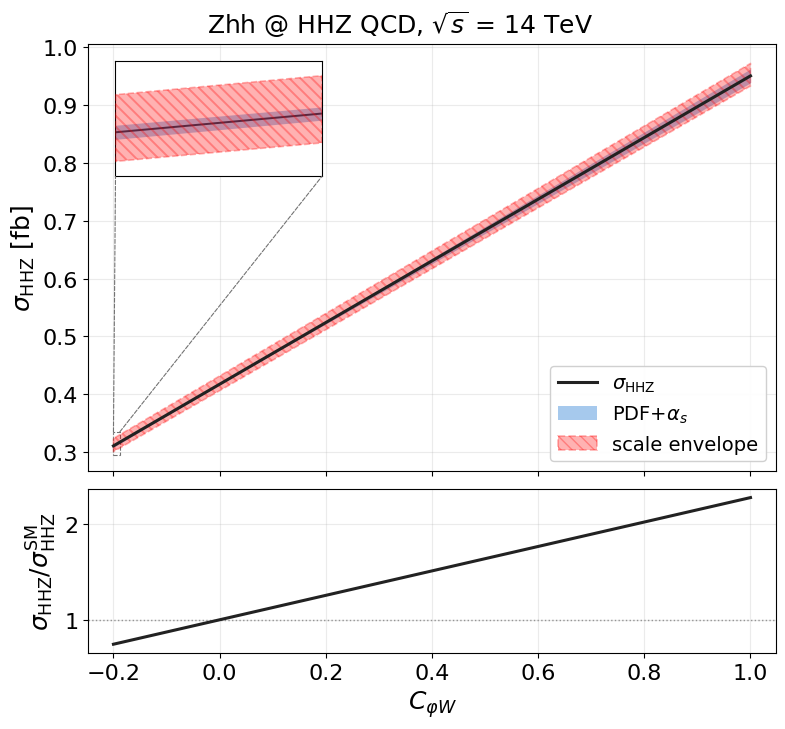

In [13]:
FIXED_WCS = {}  # SM background; e.g. {"phi": 0.0, "phiW": 0.0, ...}

scan_axis = "phiW"
scan_vmin, scan_vmax = (-0.2,1)
scan_n_points = 400

print(f"Interval for {SMEFT_WC_PLAIN[scan_axis]}: [{scan_vmin:g}, {scan_vmax:g}]")
print(f"Scan / plot window:                  [{scan_vmin:g}, {scan_vmax:g}]")

scan_data, scan_points_file = scan_and_save(
    analysis,
    scan_axis,
    vmin=scan_vmin,
    vmax=scan_vmax,
    fixed_wcs=FIXED_WCS,
    n_points=scan_n_points,
    uncertainties=True,
    save=SAVE_SCAN_POINTS,
)
if SAVE_SCAN_POINTS:
    print(f"Saved {scan_points_file}")

plot_title = default_plot_title(PROCESS, ENERGY_TEV, nn_label)
prefix = scan_plot_filename_stem(PROCESS, ENERGY_TEV, scan_axis, scan_vmin, scan_vmax)

_nnlo_kw = dict(
    style=PLOT_STYLE,
    nnlo_label=nn_label,
    xmin=scan_vmin,
    xmax=scan_vmax,
    save=SAVE_PLOTS,
)

plot_sigma_nnlo_and_kfactor(
    scan_data,
    title=plot_title,
    sigma_inset=SIGMA_INSET,
    output=PLOTS_DIR / f"{prefix}_sigma_nnlo_K.png",
    **_nnlo_kw,
)
plt.show()

plot_sigma_nnlo_and_enhancement_nnlo(
    scan_data,
    title=plot_title,
    sigma_inset=SIGMA_INSET,
    show_enhancement_uncertainty=False,
    output=PLOTS_DIR / f"{prefix}_sigma_nnlo_sigmaSM_{nn_label}.png",
    **_nnlo_kw,
)
plt.show()


## 4. Multi-axis grid scan

Vary **several Wilson coefficients at once** on a Cartesian product grid,
then write **one** `.txt` under `Results/Points/SMEFT/`.

- `FIXED_WCS` — values for WCs **not** listed in `BATCH_SCAN_AXES` (default SM = all 0)
- `BATCH_SCAN_AXES` — axes to vary **simultaneously** (e.g. `("phi", "phiW")`)
- `BATCH_SCAN_WINDOWS` — optional `{axis: (vmin, vmax)}`; defaults → `SMEFT_WC_INTERVALS`
- `BATCH_SCAN_N_POINTS` — points **per axis** (2 axes × 40 → 1600 rows)

Filename: `{Process}_{energy}TeV_{axis1}_x_{axis2}.txt`.
Set `BATCH_SCAN_AXES = ()` to skip.



In [14]:
FIXED_WCS = {}  # WCs not in BATCH_SCAN_AXES stay at SM (= 0)

# Axes varied together (Cartesian grid)
BATCH_SCAN_AXES = (
    "phi",
    "phiW",
)
BATCH_SCAN_N_POINTS = 40  # per axis
BATCH_SCAN_WINDOWS = {}

if BATCH_SCAN_AXES:
    grid_scan_data, grid_scan_path = scan_grid_and_save(
        analysis,
        BATCH_SCAN_AXES,
        windows=BATCH_SCAN_WINDOWS or None,
        n_points=BATCH_SCAN_N_POINTS,
        fixed_wcs=FIXED_WCS,
        save=SAVE_SCAN_POINTS,
        uncertainties=False,
    )
    n_rows = len(next(iter(grid_scan_data.values())))
    print(f"Grid scan: {len(BATCH_SCAN_AXES)} axis(es) × {BATCH_SCAN_N_POINTS} → {n_rows} points")
    for axis in BATCH_SCAN_AXES:
        lo, hi = (BATCH_SCAN_WINDOWS or {}).get(axis) or SMEFT_WC_INTERVALS[axis]
        print(f"  {SMEFT_WC_PLAIN[axis]}  [{lo:g}, {hi:g}]")
    print(f"  →  {grid_scan_path if SAVE_SCAN_POINTS else '(not saved)'}")
else:
    print("Grid scan skipped (BATCH_SCAN_AXES is empty).")



Grid scan: 2 axis(es) × 40 → 1600 points
  C_φ  [-15, 5]
  C_φW  [-1, 1]
  →  /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/Results/Points/SMEFT/ZHH_14TeV_phi_x_phiW.txt


## 5. SMEFT benchmark tables

Evaluates all three channels at both energies at SM and at interval boundaries for
selected Wilson coefficients. Writes LaTeX interval table to `Results/Tables/SMEFT/wc_intervals.tex`.


In [9]:
latex_path = TABLES_DIR / "wc_intervals.tex"
latex_path.write_text(latex_wc_interval_table(), encoding="utf-8")
print(f"Saved {latex_path}")

for process in CHANNELS:
    display(Markdown(f"## {process}"))
    tables = build_channel_tables(process, energies_tev=TABLE_ENERGIES_TEV)
    for key, df in tables.items():
        display(Markdown(f"### {key}"))
        display(df)


Saved /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/Results/Tables/SMEFT/wc_intervals.tex


## ZHH

### phi_phiW

,√s [TeV],Point,WC,σ_LO [fb],σ_HHZ [fb],K
0,13.6,SM,—,0.290698,0.396408,1.363641
1,13.6,min,C_φ=-15,1.336500,1.671345,1.250539
2,13.6,max,C_φ=5,-0.057903,-0.028572,0.493440
3,13.6,min,C_φW=-1,-0.137077,-0.109942,0.802045
4,13.6,max,C_φW=1,0.718473,0.902757,1.256495
5,14.0,SM,—,0.305509,0.417277,1.365842
6,14.0,min,C_φ=-15,1.402997,1.754266,1.250370
7,14.0,max,C_φ=5,-0.060320,-0.028386,0.470586
8,14.0,min,C_φW=-1,-0.145467,-0.115906,0.796784
9,14.0,max,C_φW=1,0.756485,0.950460,1.256416


### phiq3st_phiD

...

### all

,√s [TeV],Point,WC,σ_LO [fb],σ_NNLO [fb],K
0,13.6,SM,—,0.296715,0.357952,1.206382
1,13.6,min,C_φ=-15,1.415458,1.703594,1.203563
2,13.6,max,C_φ=5,-0.076199,-0.090595,1.188930
3,13.6,min,C_φ□=-1.5,-0.051147,-0.062034,1.212861
4,13.6,max,C_φ□=1.5,0.644578,0.777938,1.206896
5,13.6,min,C_φD=-2,0.265539,0.320176,1.205756
6,13.6,max,C_φD=2,0.327892,0.395729,1.206889
7,13.6,min,C_φq^(3)=-0.2,-4.649562,-5.715360,1.229226
8,13.6,max,C_φq^(3)=0.05,1.533285,1.876280,1.223700
9,13.6,min,C_φW=-1,-0.634638,-0.748986,1.180179


## WminusHH

### all

,√s [TeV],Point,WC,σ_LO [fb],σ_NNLO [fb],K
0,13.6,SM,—,0.159893,0.187135,1.170376
1,13.6,min,C_φ=-15,0.774478,0.903549,1.166656
2,13.6,max,C_φ=5,-0.044969,-0.051670,1.149020
3,13.6,min,C_φ□=-1.5,-0.026377,-0.031167,1.181600
4,13.6,max,C_φ□=1.5,0.346163,0.405437,1.171231
5,13.6,min,C_φD=-2,0.143630,0.167968,1.169453
6,13.6,max,C_φD=2,0.176156,0.206302,1.171129
7,13.6,min,C_φq^(3)=-0.2,-2.227847,-2.671423,1.199105
8,13.6,max,C_φq^(3)=0.05,0.756828,0.901774,1.191518
9,13.6,min,C_φW=-1,-0.322074,-0.375274,1.165181
